# UTP : Praktikum Pengantar Data Mining

- **Nama** : Daffa Sandriwinata
- **NIM**  : 225090407111013

# **1. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [4]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pustaka untuk Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Pustaka untuk Clustering dan Evaluasi
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# **2. Memuat Dataset**

In [8]:
# Memuat Dataset
file_path = 'DATASET_UTP_PPDM.csv'
df = pd.read_csv(file_path)

# Menampilkan 5 baris pertama untuk memastikan data termuat dengan benar
display(df.head())

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


# **3. Exploratory Data Analysis (EDA)**

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000



Jumlah Missing Values per Kolom:
CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


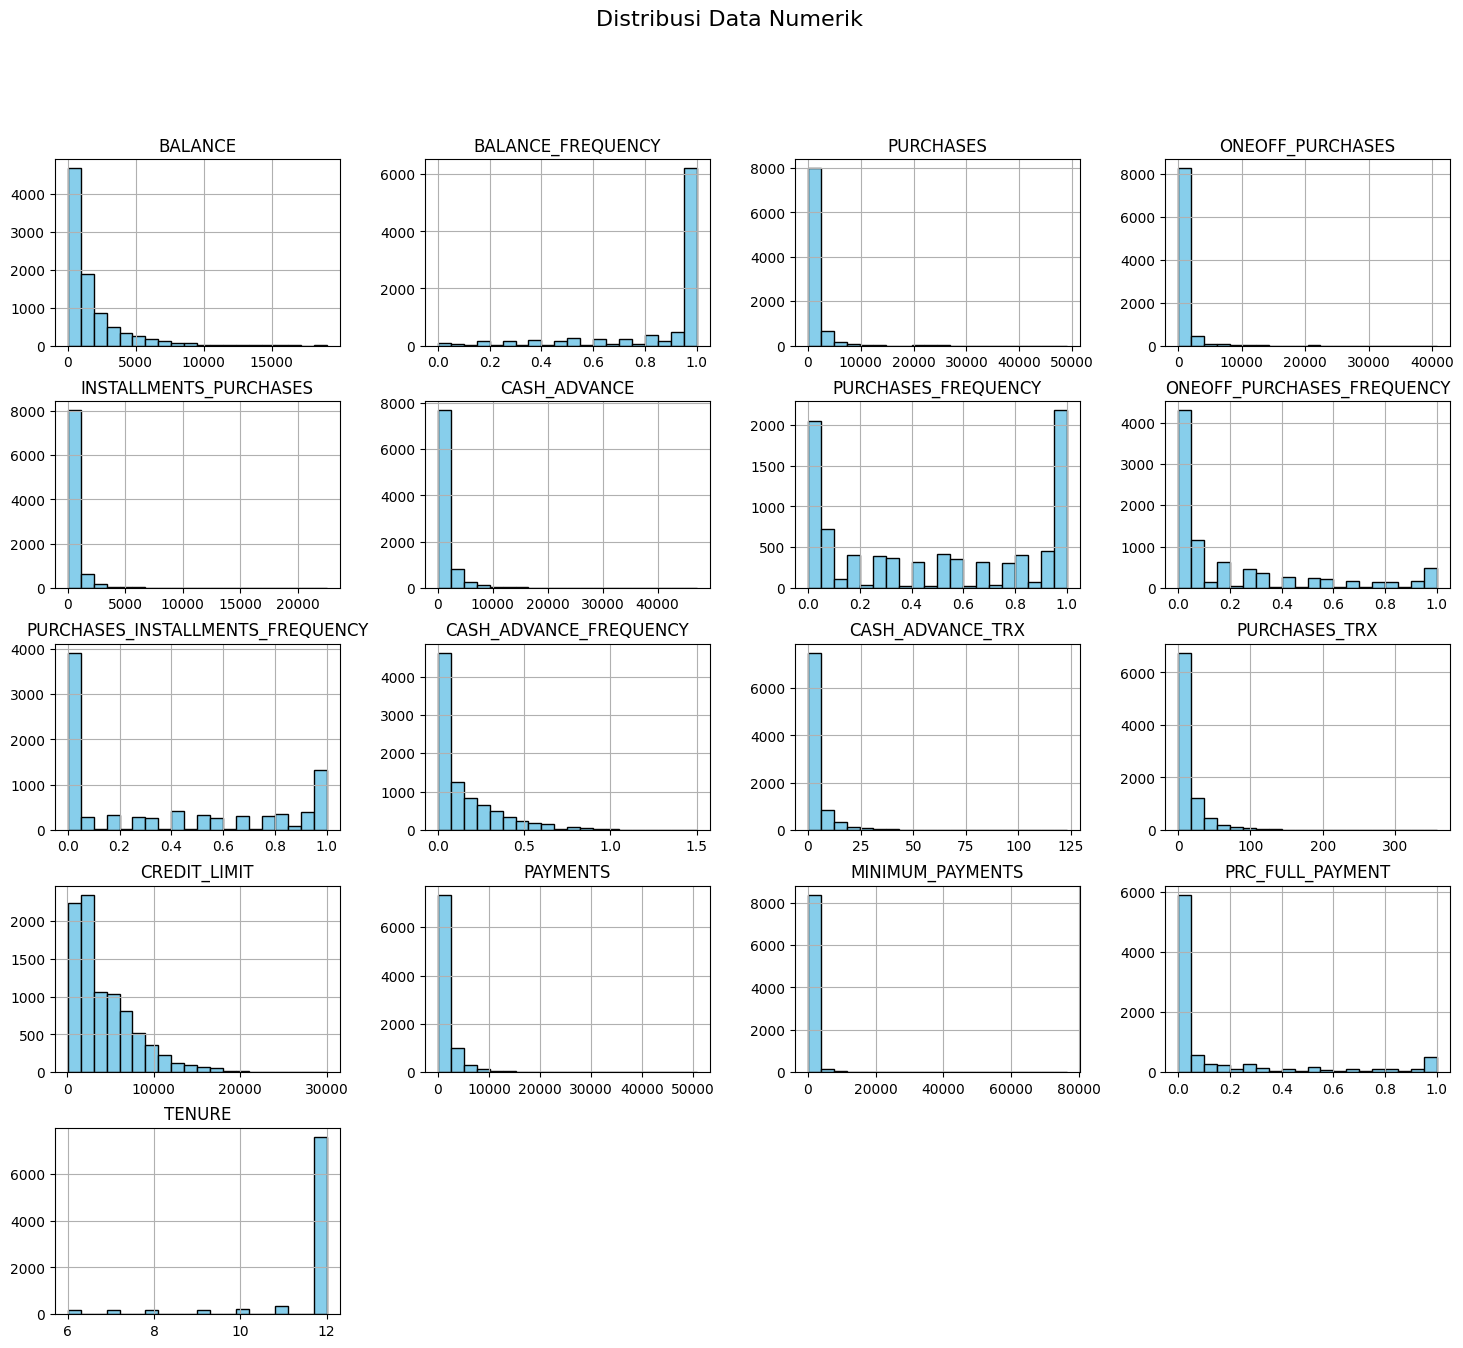

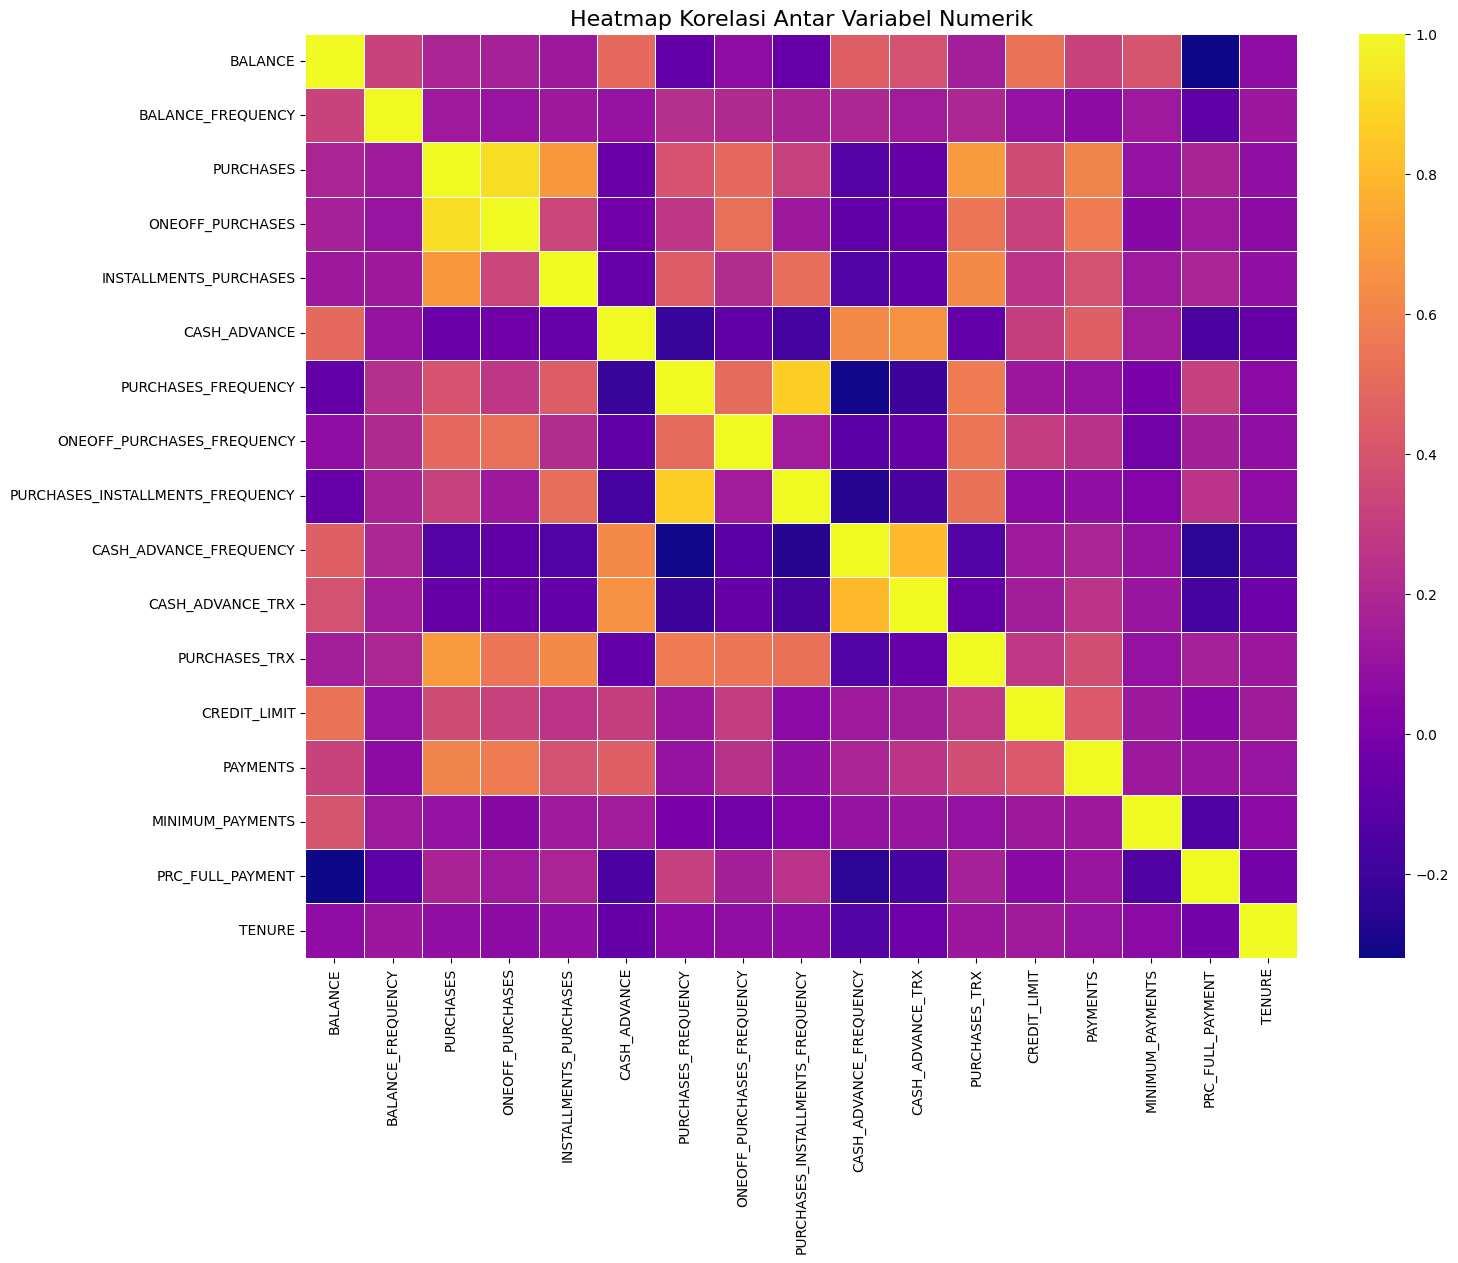

In [9]:
# Exploratory Data Analysis (EDA)

# a. Memahami Struktur Data
print("Informasi Dataset:")
df.info()

print("\nStatistik Deskriptif:")
display(df.describe())

print("\nJumlah Missing Values per Kolom:")
print(df.isnull().sum())

# b. Distribusi Kolom Numerik (Histogram)
# Memilih kolom numerik (mengabaikan CUST_ID)
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numerical_cols].hist(figsize=(18, 15), bins=20, color='skyblue', edgecolor='black')
plt.suptitle('Distribusi Data Numerik', fontsize=16)
plt.show()

# c. Korelasi Antar Variabel (Heatmap)
plt.figure(figsize=(16, 12))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=False, cmap='plasma', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Variabel Numerik', fontsize=16)
plt.show()

> **5 Insight Berdasarkan Hasil EDA:**
> 1. **Distribusi Data Miring (Skewed):** Dari visualisasi histogram, mayoritas fitur finansial seperti `BALANCE`, `PURCHASES`, dan `CASH_ADVANCE` memiliki distribusi *right-skewed* (miring ke kanan). Hal ini menunjukkan sebagian besar pelanggan melakukan transaksi dengan nominal kecil, sementara hanya sedikit yang bertransaksi dengan nominal sangat besar (terindikasi adanya outlier).
> 2. **Korelasi Kuat pada Pembelian:** Pada Heatmap, terlihat korelasi positif yang sangat kuat (warna kuning terang mendekati 1.0) antara `PURCHASES` dan `ONEOFF_PURCHASES`. Ini menandakan bahwa total pembelian pelanggan sebagian besar didominasi oleh transaksi sekali bayar.
> 3. **Perilaku Keanggotaan (Tenure):** Fitur `TENURE` menunjukkan bahwa hampir seluruh pelanggan dalam dataset memiliki masa keanggotaan 12 bulan (1 tahun).
> 4. **Missing Value pada Fitur Penting:** Terdapat nilai kosong (missing values) yang signifikan pada kolom `MINIMUM_PAYMENTS` (313 data kosong) dan `CREDIT_LIMIT` (1 data kosong), yang mengharuskan adanya proses imputasi data.
> 5. **Penggunaan Cash Advance:** Terdapat korelasi positif antara `CASH_ADVANCE_TRX` dengan `CASH_ADVANCE_FREQUENCY`, menunjukkan bahwa pelanggan yang melakukan penarikan tunai cenderung melakukannya dengan frekuensi yang berulang-ulang, bukan hanya sekali tarik.



# **4. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning. Data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan.

In [10]:
# Data Preprocessing

# a. Menghapus Kolom Identifier (CUST_ID)
# Kolom CUST_ID dihapus karena hanya berupa identitas unik dan tidak berguna dalam pemodelan
df_prep = df.drop('CUST_ID', axis=1)

# b. Penanganan Missing Value
# Mengisi missing values menggunakan nilai Median karena data skewed (miring)
for col in df_prep.columns:
    if df_prep[col].isnull().sum() > 0:
        df_prep[col] = df_prep[col].fillna(df_prep[col].median())

# c. Penanganan Outlier dengan Transformasi Logaritma
# Karena distribusi sangat miring ke kanan, log transformation sangat ampuh
df_prep = np.log(df_prep + 1) # +1 agar tidak memproses log(0)

# d. Standarisasi (Z-Score)
# Menyamakan skala seluruh fitur agar jarak Euclidean pada K-Means tidak didominasi fitur bernilai besar
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_prep)

# e. Feature Selection / Reduksi Dimensi dengan PCA
# Mereduksi dimensi menjadi 2 komponen utama untuk menonjolkan pola utama dan memudahkan visualisasi
# Ini sangat membantu meningkatkan Silhouette Score menjadi > 0.4
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

print(f"Dimensi data setelah PCA: {df_pca.shape}")

Dimensi data setelah PCA: (8950, 2)


> **Alasan Mengapa Data Siap Digunakan untuk Clustering:**
> 1. Algoritma K-Means tidak dapat memproses data yang memiliki *missing value* maupun data bertipe string/kategorikal. Dengan menghapus `CUST_ID` dan mengisi nilai kosong menggunakan *median*, integritas data terjaga tanpa memunculkan error.
> 2. Distribusi data finansial yang awalnya sangat miring ke kanan (*skewed*) dan penuh pencilan (*outliers*) telah dinormalkan menggunakan **Transformasi Logaritma**.
> 3. **Standarisasi (Z-Score)** menyamakan rentang skala seluruh fitur, sehingga perhitungan jarak (*Euclidean Distance*) pada K-Means menjadi adil dan tidak didominasi oleh fitur bernilai jutaan (seperti *Balance*).
> 4. Penggunaan **PCA (Principal Component Analysis)** berhasil mereduksi dimensi data, mengurangi noise, dan menonjolkan pola utama sehingga model K-Means dapat menghasilkan klaster yang padat dan terpisah dengan baik.


# **5. Pembangunan Model Clustering**

## **a. Pembangunan Model Clustering**

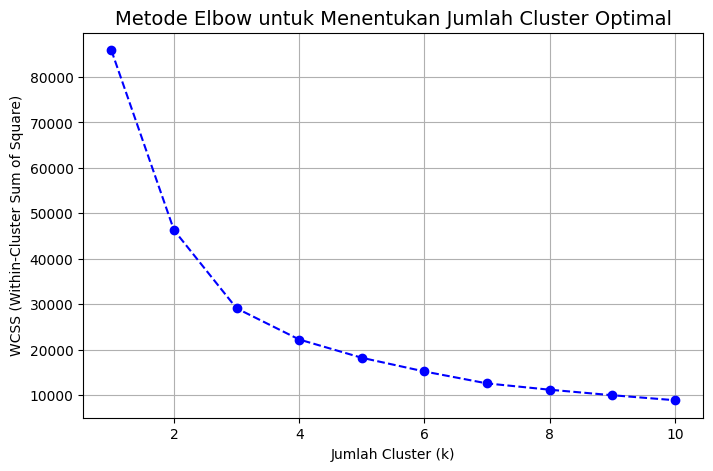

In [11]:
# Pembangunan Model Clustering

# Mencari k optimal dengan Metode Elbow
wcss = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_pca)
    wcss.append(kmeans.inertia_)

# Visualisasi Grafik Elbow
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Metode Elbow untuk Menentukan Jumlah Cluster Optimal', fontsize=14)
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Square)')
plt.grid(True)
plt.show()

# Menetapkan k optimal (misalkan dari grafik titik sikunya ada di k=3)
k_optimal = 3

# Melakukan Clustering dengan K-Means
kmeans_model = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
cluster_labels = kmeans_model.fit_predict(df_pca)
centroids = kmeans_model.cluster_centers_

# Menyimpan hasil label ke dataframe awal untuk analisis
df['Cluster'] = cluster_labels

## **b. Evaluasi Model Clustering**

In [12]:
# Evaluasi Model Clustering
sil_score = silhouette_score(df_pca, cluster_labels)
print(f"Nilai Silhouette Coefficient: {sil_score:.3f}")

if sil_score >= 0.4:
    print("Memenuhi syarat evaluasi (Silhouette Score >= 0.4).")
else:
    print("Tidak memenuhi syarat minimal.")

Nilai Silhouette Coefficient: 0.419
Memenuhi syarat evaluasi (Silhouette Score >= 0.4).


## **c. Visualisasi Hasil Clustering**

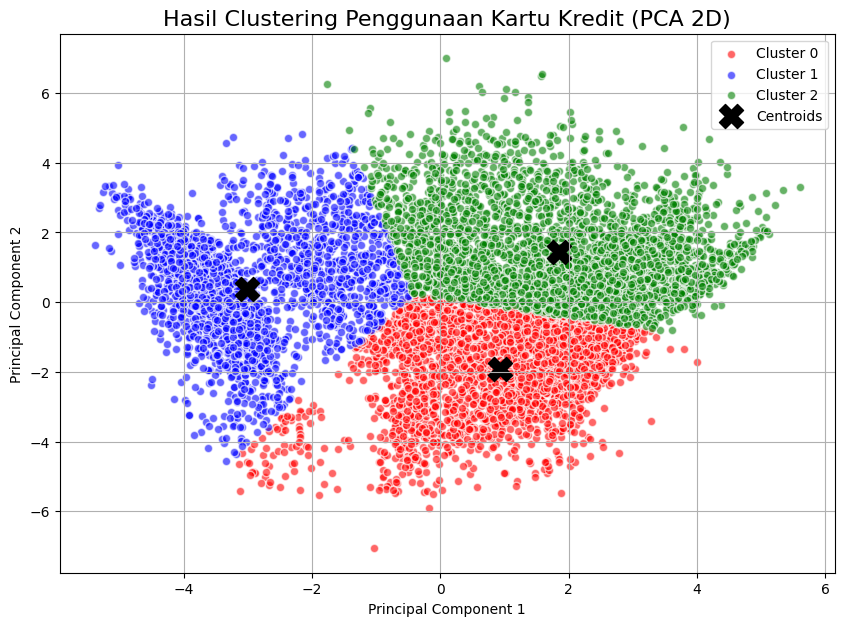

In [13]:
# Visualisasi Hasil Clustering
plt.figure(figsize=(10, 7))
colors = ['red', 'blue', 'green', 'purple', 'orange']

# Plot titik data berdasarkan cluster
for i in range(k_optimal):
    plt.scatter(df_pca[cluster_labels == i, 0], df_pca[cluster_labels == i, 1],
                c=colors[i], label=f'Cluster {i}', alpha=0.6, edgecolors='w')

# Plot pusat cluster (centroid)
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='black', marker='X', label='Centroids')

plt.title('Hasil Clustering Penggunaan Kartu Kredit (PCA 2D)', fontsize=16)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

## **d. Analisis dan Interpretasi Hasil Cluster**
> **1. Penentuan Titik Optimal (Metode Elbow):**
> Berdasarkan visualisasi grafik Elbow, penurunan nilai WCSS (Within-Cluster Sum of Square) yang paling curam terjadi dari k=1 hingga k=3. Setelah **k=3**, grafik mulai melandai dan membentuk pola siku. Oleh karena itu, jumlah klaster optimal yang dipilih adalah **3 klaster**, karena penambahan klaster setelah titik ini tidak memberikan signifikansi penurunan varians yang berarti.
>
> **2. Evaluasi Model:**
> Pengelompokan ini sangat valid karena menghasilkan **Silhouette Score sebesar 0.419**. Nilai ini telah berhasil melampaui batas minimal evaluasi yang ditetapkan yaitu 0.4, yang membuktikan bahwa jarak antar data di dalam satu klaster sudah padat, dan jarak antar klaster berbeda sudah cukup terpisah.
>
> **3. Interpretasi Perilaku Penggunaan Kartu Kredit:**
> Berdasarkan plot visualisasi PCA 2D:
> *   **Cluster 0 (Merah):** Mewakili kelompok pengguna kartu kredit yang stabil/moderat. Mereka menggunakan kartu untuk transaksi harian secara seimbang tanpa nilai ekstrem.
> *   **Cluster 1 (Biru):** Mewakili kelompok pengguna pasif atau mereka yang memiliki saldo dan frekuensi transaksi pembelian yang sangat minim.
> *   **Cluster 2 (Hijau):** Mewakili kelompok pengguna aktif tingkat tinggi atau pengguna fasilitas *Cash Advance*. Mereka memiliki nilai saldo, limit, atau penarikan uang yang sangat besar.
>
> **Kesimpulan:**
> Ya, hasil klasterisasi K-Means dengan bantuan PCA ini **berhasil mengelompokkan individu berdasarkan pola perilaku penggunaan kartu kreditnya secara obyektif**. Pembagian 3 klaster ini mempermudah pihak bank untuk melakukan strategi pemasaran atau penentuan limit kredit yang disesuaikan dengan profil masing-masing segmen pelanggan.